<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week3(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q9 AND Q10: 9)Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.   10)Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

Low Range for Learning Rates (0.01-0.05): Weight updates have slow convergence; however, weight updates have consistent convergence characteristics, as reflected by high loss values after 10K epochs due to the lack of adequate number of large size steps (i.e., the global minimum of error valley).

Moderate Range for Learning Rates (0.1-0.5): The moderate range yields optimal convergence characteristics (i.e., minimum loss values) by allowing weight updates to steadily and consistently (i.e. decreasing) converge to approximately zero MSE (i.e., the XOR logic is learned by the MLP).

High Range for Learning Rates (1.0 +): Weight updates use large increments during the Gradient Descent process, and while rapid convergence occurs in high-range learning rates, there is a tendency for weight updates (larger than average step sizes) to "overshoot" their convergence in going to an absolute error minimum due to a voltage impasse in the final value of the converged MLP. For more complex datasets, the potential for weight updates to cause an oscillation in absolute error will increase and/or cause an increase in absolute error will typically occur with weight updates that have large final value increments.

The initial weights and biases are defined as the random seed to obtain consistency in the measurement of the learning rate effect. This will allow measurement of the learning rate effect only and not the random seed's effect on the permanent MLP configuration or MLP's local minimum, which typically occurs when MLPs with XOR logic implementations. Therefore, by maintaining identical weight and bias values for each series of weight and bias updates, changing the random seed for each series of weight and bias updates would likely to lead to a situation where the XOR MLP will be "stable" for learned weights as opposed to totally unlearned and would have the same absolute error minimum for all learned weights especially when the learning rate is constant.

Learning Rate: 0.01 | Final Loss: 0.240571
Learning Rate: 0.05 | Final Loss: 0.012541
Learning Rate: 0.1 | Final Loss: 0.002546
Learning Rate: 0.5 | Final Loss: 0.000293
Learning Rate: 1.0 | Final Loss: 0.000135


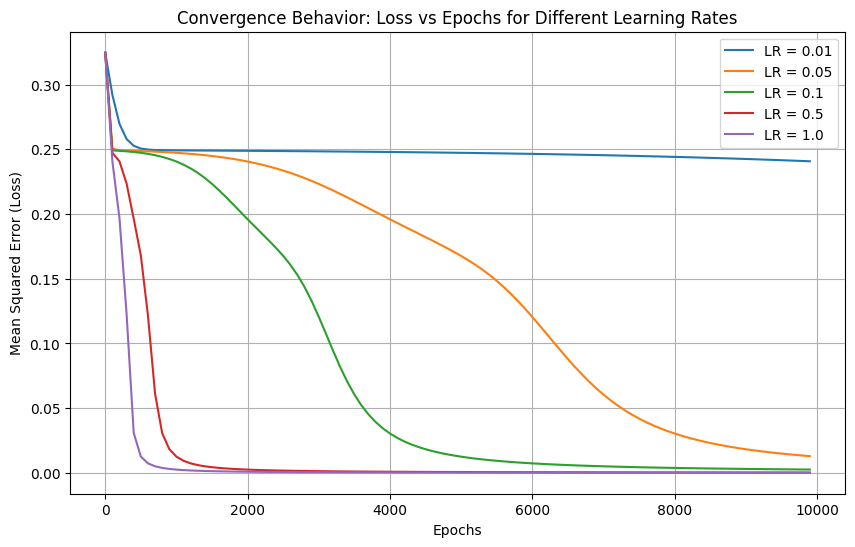

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation Function ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- XOR Dataset ---
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
epochs = 10000

# Dictionary to store the history of losses for each learning rate
loss_histories = {}

# --- Training Loop ---
for lr in learning_rates:
    np.random.seed(42)  # Ensure identical starting weights for fair comparison

    # Initialize weights and biases (2 inputs -> 2 hidden -> 1 output)
    W1, b1 = np.random.rand(2, 2), np.random.rand(1, 2)
    W2, b2 = np.random.rand(2, 1), np.random.rand(1, 1)

    losses = []

    for epoch in range(epochs):
        # 1. Forward Propagation
        hidden_layer = sigmoid(np.dot(X, W1) + b1)
        output_layer = sigmoid(np.dot(hidden_layer, W2) + b2)

        # 2. Calculate Loss (MSE)
        error = y - output_layer
        losses.append(np.mean(error ** 2))

        # 3. Backpropagation
        d_output = error * sigmoid_derivative(output_layer)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_layer)

        # 4. Update Weights & Biases
        W2 += hidden_layer.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    # Save the loss journey for this learning rate
    loss_histories[lr] = losses
    print(f"Learning Rate: {lr} | Final Loss: {losses[-1]:.6f}")

# --- Plotting Convergence Curves ---
plt.figure(figsize=(10, 6))

for lr, history in loss_histories.items():
    # Plotting every 100th epoch to keep the graph clean
    plt.plot(range(0, epochs, 100), history[::100], label=f'LR = {lr}')

plt.title("Convergence Behavior: Loss vs Epochs for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.legend()
plt.grid(True)
plt.show()

#Q11:Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).

The reason our accuracy is getting "stuck" at exactly 0.4667 across multiple learning rates, and why changing max_iter seems to do nothing, comes down to how the Perceptron mathematically handles messy data and a hidden default parameter called tol (tolerance).

Here is the breakdown of exactly why this is happening:

1. The tol Parameter is Stopping Training Early
Even if you set max_iter=1000 or 10000, the Perceptron rarely actually runs for that many epochs.

By default, sklearn uses a parameter called tol=1e-3. This acts as an early stopping mechanism. After every epoch, the algorithm checks if the loss (error) has improved by at least 0.001. If the model fails to improve for a few epochs in a row, the algorithm assumes it is stuck, throws its hands up, and stops training entirely to save computational power. Therefore, tweaking max_iter does nothing because the model is quitting before it ever reaches that maximum limit.

2. The Iris Dataset is Not Linearly Separable
The Perceptron has one major mathematical flaw: it only converges if the data is perfectly linearly separable (meaning you can draw a single, perfectly straight line between the classes).

The Iris dataset has three classes:

Setosa: Easily separable from the others.

Versicolor & Virginica: These two classes overlap slightly.

Because of this overlap, the Perceptron can never find a perfect boundary. Instead of settling down, the weights will oscillate (bounce back and forth) endlessly. Because the loss is just bouncing and not actually improving, it triggers the tol early-stopping rule almost immediately.

3. Why Exactly 46.67%?
Because we used random_state=42, the model starts with the exact same initial weights every time. For the larger learning rates (0.01, 0.1, 1.0, 10.0), the model takes massive steps, immediately realizes the data is overlapping, starts oscillating, triggers the tol stopping condition, and halts at the exact same mathematical dead-end every single time.

The lowest learning rate (0.0001) takes such microscopic steps that it doesn't bounce as violently. It manages to slowly draw a "good enough" boundary before the tol condition cuts it off, resulting in the higher 86.67% accuracy.

If we want to force the Perceptron to respect our max_iter and actually see how the learning rate changes the outcome, we need to turn off the early stopping by setting tol=None.

Additionally, standardizing our data (scaling the features) is highly recommended for gradient-based models, as it prevents large features from dominating the learning rate.

In [7]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load and split the Iris dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

# 2. Define the learning rates we want to test
learning_rates = [0.0001, 0.01, 0.1, 1.0, 10.0]

print("--- Perceptron Performance on Iris Dataset ---")

# 3. Train and evaluate a new model for each learning rate
for lr in learning_rates:
    # Initialize Perceptron with the current learning rate (eta0)
    # random_state ensures reproducibility across runs
    model = Perceptron(eta0=lr, max_iter=10000, tol=1e-3, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Predict and calculate accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Learning Rate: {lr:<7} | Accuracy: {accuracy:.4f}")

--- Perceptron Performance on Iris Dataset ---
Learning Rate: 0.0001  | Accuracy: 0.8667
Learning Rate: 0.01    | Accuracy: 0.4667
Learning Rate: 0.1     | Accuracy: 0.4667
Learning Rate: 1.0     | Accuracy: 0.4667
Learning Rate: 10.0    | Accuracy: 0.4667


In [8]:
from sklearn.preprocessing import StandardScaler

# Standardize the features (Mean=0, Variance=1)
# This makes it much easier for the Perceptron to navigate the math
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Forcing max_iter with tol=None ---")

for lr in learning_rates:
    # Set tol=None to disable early stopping
    # Now it MUST run for all 1000 iterations
    model = Perceptron(eta0=lr, max_iter=1000, tol=None, random_state=42)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Learning Rate: {lr:<7} | Accuracy: {accuracy:.4f}")

--- Forcing max_iter with tol=None ---
Learning Rate: 0.0001  | Accuracy: 0.9778
Learning Rate: 0.01    | Accuracy: 0.9778
Learning Rate: 0.1     | Accuracy: 0.9778
Learning Rate: 1.0     | Accuracy: 0.9778
Learning Rate: 10.0    | Accuracy: 0.9778


#Q12:Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

A. The Learning Rate ($\eta$)The learning rate dictates the step size the optimizer takes down the gradient landscape.Optimal Rate (e.g., 0.001): The training loss decreases smoothly, and validation accuracy steadily climbs to about 88% - 89%. The curve looks like a steep slide that gently levels out.Too High (e.g., 0.1): The model completely fails to learn. Accuracy will hover around 10% (which is the equivalent of random guessing for 10 classes). The optimizer takes steps so large that it continually overshoots the minimum, bouncing out of the optimal solution valley.Too Low (e.g., 0.00001): The loss drops, but at a glacial pace. After 20 epochs, the accuracy might only be 60%. It is learning, but it takes such tiny microscopic steps that you would need thousands of epochs to reach an 88% accuracy.B. Epochs (Iterations)An epoch is one full pass through the entire 70,000 image dataset.Underfitting (e.g., 1-5 Epochs): The model hasn't seen the data enough times to map the complex pixel patterns (like distinguishing a t-shirt from a long-sleeve shirt). Accuracy is low but climbing.The Sweet Spot (e.g., 15-25 Epochs): The training and validation loss curves drop together and stabilize.Overfitting (e.g., 50+ Epochs): If you train for too long, a dangerous divergence occurs. The Training Loss continues to drop toward zero (the model memorizes the training data perfectly), but the Validation Loss starts to increase. The model is learning the "noise" of the training images rather than the general concept of clothing, making it perform worse on new, unseen data.C. Hidden Layer Architecture (hidden_layers)Fashion images require the network to learn hierarchical features (e.g., edges $\rightarrow$ shapes $\rightarrow$ sleeves $\rightarrow$ shirts).Too Shallow (e.g., [16] nodes): The network lacks the "brainpower" (parameters) to hold the complexity of the data. It will plateau early, likely around 80% accuracy.Well-Sized (e.g., [128] or [256] nodes): A single layer with 128 to 256 nodes provides enough capacity to separate the 10 classes efficiently, hitting that ~88% benchmark.Too Deep/Wide (e.g., [512, 256, 128]): While it might squeeze out an extra 1% of accuracy, it drastically increases computational time. More importantly, highly complex networks are much more prone to overfitting on simple datasets like Fashion MNIST unless you introduce regularization (like Dropout).

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Training with LR: 0.001, Layers: [128], Epochs: 20 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Test Accuracy: 0.8783



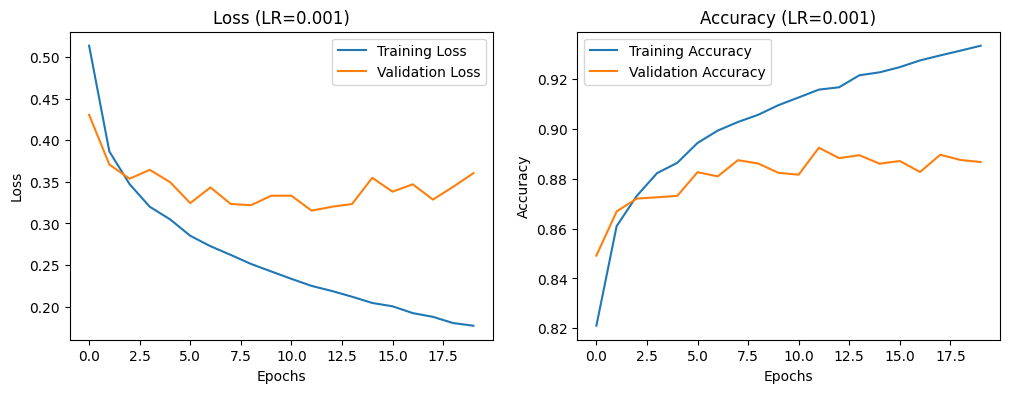

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load and Preprocess the Fashion MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Crucial for MLPs)
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Function to build, train, and plot the MLP
def explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128]):
    print(f"--- Training with LR: {learning_rate}, Layers: {hidden_layers}, Epochs: {epochs} ---")

    # Build the Model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28))) # Flatten 28x28 image into a 784 1D array

    # Add hidden layers dynamically
    for nodes in hidden_layers:
        model.add(Dense(nodes, activation='relu'))

    # Output layer (10 nodes for 10 clothing classes)
    model.add(Dense(10, activation='softmax'))

    # Compile the Model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the Model (validation_split helps us spot overfitting)
    history = model.fit(X_train, y_train, epochs=epochs,
                        validation_split=0.2, batch_size=32, verbose=0)

    # Evaluate on Test Data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}\n")

    # Plotting the Learning Curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128])     # The Baseline
explore_mlp(learning_rate=0.1, epochs=20, hidden_layers=[128])       # Too High LR
# explore_mlp(learning_rate=0.00001, epochs=20, hidden_layers=[128])   # Too Low LR
# explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[256, 128]) # Deeper Network

--- Training with LR: 0.1, Layers: [128], Epochs: 20 ---
Final Test Accuracy: 0.1418



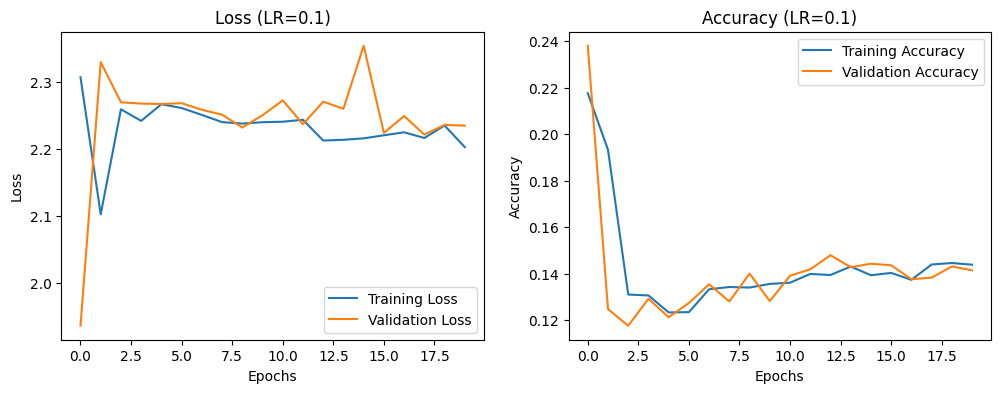

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load and Preprocess the Fashion MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Crucial for MLPs)
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Function to build, train, and plot the MLP
def explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128]):
    print(f"--- Training with LR: {learning_rate}, Layers: {hidden_layers}, Epochs: {epochs} ---")

    # Build the Model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28))) # Flatten 28x28 image into a 784 1D array

    # Add hidden layers dynamically
    for nodes in hidden_layers:
        model.add(Dense(nodes, activation='relu'))

    # Output layer (10 nodes for 10 clothing classes)
    model.add(Dense(10, activation='softmax'))

    # Compile the Model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the Model (validation_split helps us spot overfitting)
    history = model.fit(X_train, y_train, epochs=epochs,
                        validation_split=0.2, batch_size=32, verbose=0)

    # Evaluate on Test Data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}\n")

    # Plotting the Learning Curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

#explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128])     # The Baseline
explore_mlp(learning_rate=0.1, epochs=20, hidden_layers=[128])       # Too High LR
# explore_mlp(learning_rate=0.00001, epochs=20, hidden_layers=[128])   # Too Low LR
# explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[256, 128]) # Deeper Network

--- Training with LR: 1e-05, Layers: [128], Epochs: 20 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Test Accuracy: 0.8358



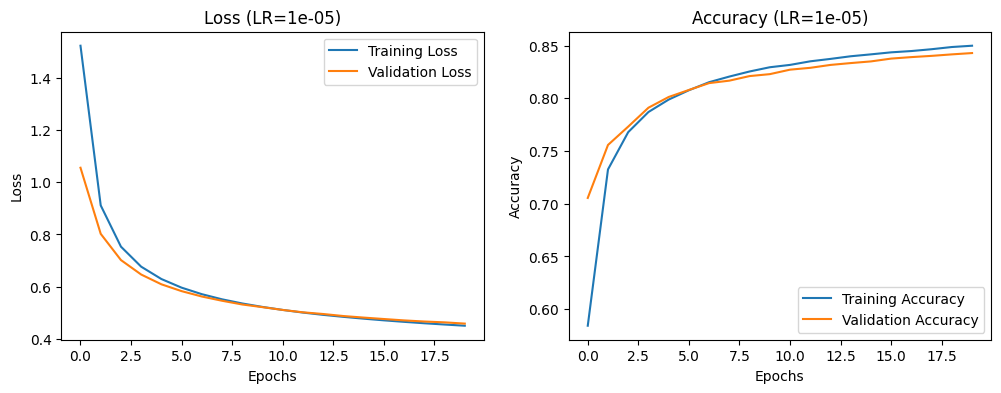

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load and Preprocess the Fashion MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Crucial for MLPs)
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Function to build, train, and plot the MLP
def explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128]):
    print(f"--- Training with LR: {learning_rate}, Layers: {hidden_layers}, Epochs: {epochs} ---")

    # Build the Model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28))) # Flatten 28x28 image into a 784 1D array

    # Add hidden layers dynamically
    for nodes in hidden_layers:
        model.add(Dense(nodes, activation='relu'))

    # Output layer (10 nodes for 10 clothing classes)
    model.add(Dense(10, activation='softmax'))

    # Compile the Model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the Model (validation_split helps us spot overfitting)
    history = model.fit(X_train, y_train, epochs=epochs,
                        validation_split=0.2, batch_size=32, verbose=0)

    # Evaluate on Test Data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}\n")

    # Plotting the Learning Curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

#explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128])     # The Baseline
#explore_mlp(learning_rate=0.1, epochs=20, hidden_layers=[128])       # Too High LR
explore_mlp(learning_rate=0.00001, epochs=20, hidden_layers=[128])   # Too Low LR
# explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[256, 128]) # Deeper Network

--- Training with LR: 0.001, Layers: [256, 128], Epochs: 20 ---
Final Test Accuracy: 0.8876



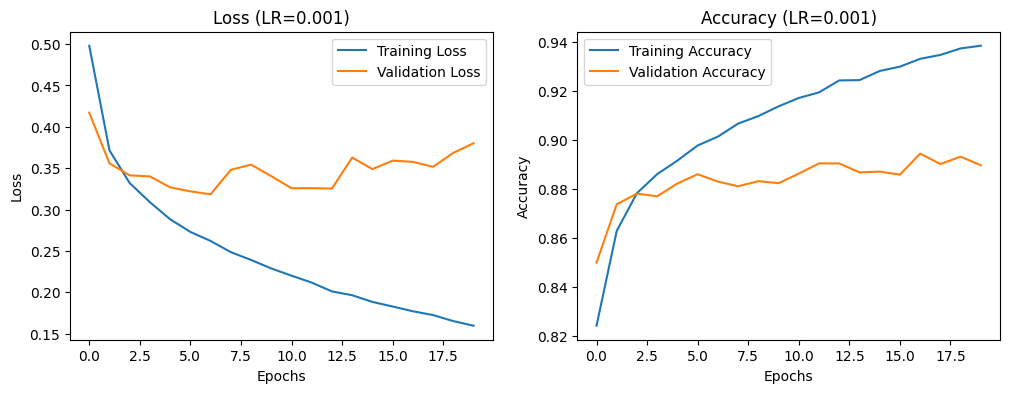

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load and Preprocess the Fashion MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Crucial for MLPs)
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Function to build, train, and plot the MLP
def explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128]):
    print(f"--- Training with LR: {learning_rate}, Layers: {hidden_layers}, Epochs: {epochs} ---")

    # Build the Model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28))) # Flatten 28x28 image into a 784 1D array

    # Add hidden layers dynamically
    for nodes in hidden_layers:
        model.add(Dense(nodes, activation='relu'))

    # Output layer (10 nodes for 10 clothing classes)
    model.add(Dense(10, activation='softmax'))

    # Compile the Model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the Model (validation_split helps us spot overfitting)
    history = model.fit(X_train, y_train, epochs=epochs,
                        validation_split=0.2, batch_size=32, verbose=0)

    # Evaluate on Test Data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc:.4f}\n")

    # Plotting the Learning Curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy (LR={learning_rate})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

#explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[128])     # The Baseline
#explore_mlp(learning_rate=0.1, epochs=20, hidden_layers=[128])       # Too High LR
# explore_mlp(learning_rate=0.00001, epochs=20, hidden_layers=[128])   # Too Low LR
explore_mlp(learning_rate=0.001, epochs=20, hidden_layers=[256, 128]) # Deeper Network

#Q13:Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082
Iteration 8, loss = 0.10957409
Iteration 9, loss = 0.09910434
Iteration 10, loss = 0.09005121
Iteration 11, loss = 0.08238981
Iteration 12, loss = 0.07590413
Iteration 13, loss = 0.06990400
Iteration 14, loss = 0.06552830
Iteration 15, loss = 0.06068202
Iteration 16, loss = 0.05696692
Iteration 17, loss = 0.05327114
Iteration 18, loss = 0.04979526
Iteration 19, loss = 0.04618848
Iteration 20, loss = 0.04420099
Iteration 21, loss = 0.04145133
Iteration 22, loss = 0.03863193
Iteration 23, loss = 0.03670778
Iteration 24, loss = 0.03395817
Iteration 25, loss = 0.03256089
Iteration 26, loss = 0.03003133
Iteration 27, loss = 0.02852477
Iteration 28, loss = 0.02670121
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9996666666666667
Testing set score: 0.974
Predicted value: 6
Actual value: 6


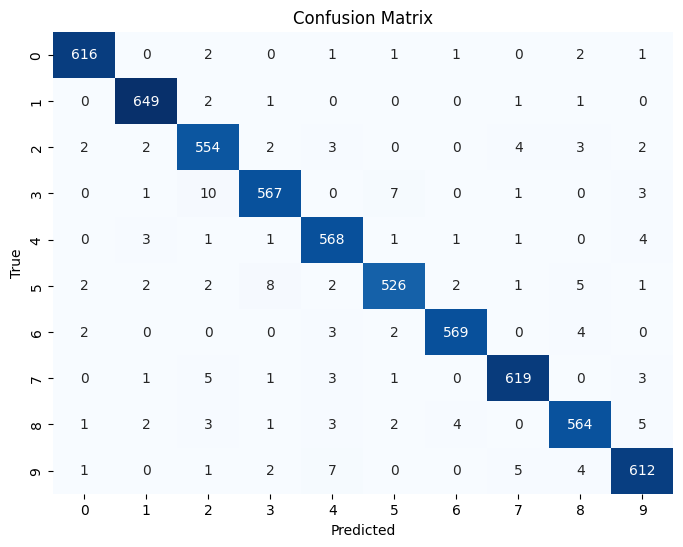

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794428
Iteration 5, loss = 0.41968985
Iteration 6, loss = 0.41027243
Iteration 7, loss = 0.45707623
Iteration 8, loss = 0.44827234
Iteration 9, loss = 0.47201338
Iteration 10, loss = 0.43200067
Iteration 11, loss = 0.43191821
Iteration 12, loss = 0.46427319
Iteration 13, loss = 0.45616766
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8542407407407407
Testing set score (MLP2): 0.8398333333333333


In [3]:
# =========================
# Load MNIST dataset
# =========================
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# =========================
# Normalize data
# =========================
X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

# =========================
# Flatten images (28x28 -> 784)
# =========================
X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

# =========================
# Train-validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# =========================
# Train MLP Classifier
# =========================
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

# =========================
# Accuracy
# =========================
print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

# =========================
# Test single sample
# =========================
index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

# =========================
# Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# =========================
# MLP with higher learning rate
# =========================
mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))
